# 304 — Robust decision analysis for depletion_q uncertainty

This is the main **decision-focused** notebook for the depletion-q workflow.

It combines:

1. **Robust decision metrics** from the joint T/S uncertainty analysis (`302b`)
2. **Best / baseline / percentile / worst-case streamflow structure**
3. **A local streamflow-uncertainty interpretation**
4. **Threshold-based shortfall risk**
5. **Robust pumping decisions by threshold and reliability**

This notebook does **not** rerun PyCap. It reads the completed joint T/S uncertainty outputs from `302b`.


## 1. Imports, helper reload, and user controls

Main controls:

- `STREAMFLOW_THRESHOLDS_CFS` are the threshold values used in the robust-decision analysis.
- `RELIABILITY_LEVELS` are the target reliability levels.
- `TARGET_PUMPING_CFS` controls the local uncertainty view.
- `LOCAL_WINDOW_HALF_WIDTH_CFS` controls the width of the local pumping window.
- `LOCAL_SHORTFALL_THRESHOLD_CFS` is the threshold used only for the local shortfall illustration.


In [119]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

sys.modules.pop("uncertainty_project_helpers_depletion_q", None)
importlib.invalidate_caches()
import uncertainty_project_helpers_depletion_q as up

print("Helper imported from:", up.__file__)
print("Helper version:", getattr(up, "HELPER_VERSION", "unknown"))

PROJECT_DIR = up.find_lpr_pycap_opt_dir()
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "Uncertainty_Project_depletion_q"
PROJECT_OUTPUT_DIR = NOTEBOOK_DIR / "project_output"
OUTPUT_DIR = PROJECT_OUTPUT_DIR / "304_robust_decision_analysis_depletion_q"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Controls
# -----------------------------------------------------------------------------
STREAMFLOW_THRESHOLDS_CFS = [5.0, 6.0, 7.0]
RELIABILITY_LEVELS = [0.80, 0.90, 0.95]

TARGET_PUMPING_CFS = 29.0
LOCAL_WINDOW_HALF_WIDTH_CFS = 1.2
LOCAL_SHORTFALL_THRESHOLD_CFS = 6.982  # NOTE: update this so it hits the target pumping's streamflow cfs

# -----------------------------------------------------------------------------
# Style palettes
# -----------------------------------------------------------------------------
# Main uncertainty plots
BASELINE_COLOR = "#1f77b4"            # blue
BEST_COLOR = "#2ca25f"                # green
P95_COLOR = "#74c476"                 # lighter green
P05_COLOR = "#fc9272"                 # lighter red
WORST_COLOR = "#cb181d"               # red
FULL_FILL_COLOR = "#c6dbef"           # light blue
PERCENTILE_FILL_COLOR = "#fdd0a2"     # light orange

# Threshold-related plots
THRESHOLD_COLORS = {
    5.0: "#9ecae1",   # dark blue 9ecae1
    6.0: "#4292c6",   # medium blue
    7.0: "#08519c",   # light blue
}
RELIABILITY_STYLES = {
    0.80: {"color": "0.25", "linestyle": "--", "linewidth": 1.4},
    0.90: {"color": "0.45", "linestyle": "-.", "linewidth": 1.4},
    0.95: {"color": "0.65", "linestyle": ":", "linewidth": 1.6},
}
RELIABILITY_BAR_STYLES = {
    0.80: {"alpha": 0.45, "hatch": "//"},
    0.90: {"alpha": 0.70, "hatch": "\\\\"},
    0.95: {"alpha": 1.00, "hatch": ""},
}

up.apply_plot_style()

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("STREAMFLOW_THRESHOLDS_CFS:", STREAMFLOW_THRESHOLDS_CFS)
print("RELIABILITY_LEVELS:", RELIABILITY_LEVELS)
print("TARGET_PUMPING_CFS:", TARGET_PUMPING_CFS)
print("LOCAL_SHORTFALL_THRESHOLD_CFS:", LOCAL_SHORTFALL_THRESHOLD_CFS)


Helper imported from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py
Helper version: 2026-05-24_depletion_q_304_v7_full_uncertainty_annotation_higher
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q
STREAMFLOW_THRESHOLDS_CFS: [5.0, 6.0, 7.0]
RELIABILITY_LEVELS: [0.8, 0.9, 0.95]
TARGET_PUMPING_CFS: 29.0
LOCAL_SHORTFALL_THRESHOLD_CFS: 6.982


## 2. Load 302b joint T/S uncertainty results

This notebook reads the completed `302b` joint T/S uncertainty outputs.
The long re-evaluation table is the main source used below.


In [120]:
def first_existing(paths, label, required=True):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    if required:
        searched = "\n".join(str(Path(p)) for p in paths)
        raise FileNotFoundError(f"Could not find {label}. Searched:\n{searched}")
    return None


DIR_302B = PROJECT_OUTPUT_DIR / "302b_joint_T_storage_probability_weighted_uncertainty_depletion_q"

path_long = first_existing(
    [DIR_302B / "302b_joint_T_storage_probability_reevaluation_long.csv"],
    "302b long uncertainty results",
)
path_member = first_existing(
    [DIR_302B / "302b_joint_T_storage_probability_weighted_member_summary.csv"],
    "302b member summary",
    required=False,
)
path_overall = first_existing(
    [DIR_302B / "302b_joint_T_storage_probability_weighted_overall_summary.csv"],
    "302b overall summary",
    required=False,
)

results_long = pd.read_csv(path_long)
results_long["member"] = results_long["member"].astype(str)

member_summary_302b = pd.read_csv(path_member) if path_member and path_member.exists() else pd.DataFrame()
if not member_summary_302b.empty:
    member_summary_302b["member"] = member_summary_302b["member"].astype(str)

overall_summary_302b = pd.read_csv(path_overall) if path_overall and path_overall.exists() else pd.DataFrame()

print("Loaded long table:", results_long.shape)
print("Loaded member summary:", member_summary_302b.shape)
print("Loaded overall summary:", overall_summary_302b.shape)

display(results_long.head())
if not member_summary_302b.empty:
    display(member_summary_302b.head())
if not overall_summary_302b.empty:
    display(overall_summary_302b.head())


Loaded long table: (7400, 22)
Loaded member summary: (296, 33)
Loaded overall summary: (16, 2)


,member,generation,scenario,base_T_value,base_S_value,archive_pumping_objective_cfs,pumping_objective_reeval_cfs,full_model_total_pumping_cfs,archive_depletion_cfs,depletion_cfs,...,S_z_score,T_factor,S_factor,T_value,S_value,diffusivity_factor,T_probability_weight,S_probability_weight,joint_probability_weight,scenario_label
0,152,50,Tzminus2p00_Szminus2p00,1700.0,0.12,39.085358,39.085441,117.697971,4.782580,4.782582,...,-2.0,0.8,0.8,1360.0,0.096,1.0,0.054489,0.054489,0.002969,"T 0.80, S 0.80"
1,gen=36_member=6021_pso,50,Tzminus2p00_Szminus2p00,1700.0,0.12,15.730438,15.730429,94.342958,0.811083,0.811083,...,-2.0,0.8,0.8,1360.0,0.096,1.0,0.054489,0.054489,0.002969,"T 0.80, S 0.80"
2,16,50,Tzminus2p00_Szminus2p00,1700.0,0.12,38.467534,38.467529,117.080058,4.489270,4.489274,...,-2.0,0.8,0.8,1360.0,0.096,1.0,0.054489,0.054489,0.002969,"T 0.80, S 0.80"
3,130,50,Tzminus2p00_Szminus2p00,1700.0,0.12,38.600100,38.600146,117.212675,4.690710,4.690711,...,-2.0,0.8,0.8,1360.0,0.096,1.0,0.054489,0.054489,0.002969,"T 0.80, S 0.80"
4,95,50,Tzminus2p00_Szminus2p00,1700.0,0.12,38.900657,38.900681,117.513211,4.701270,4.701268,...,-2.0,0.8,0.8,1360.0,0.096,1.0,0.054489,0.054489,0.002969,"T 0.80, S 0.80"


,member,pumping_objective_reeval_cfs,baseline_streamflow_cfs,baseline_depletion_cfs,expected_streamflow_cfs,expected_depletion_cfs,expected_streamflow_bias_from_baseline_cfs,expected_depletion_bias_from_baseline_cfs,probability_weighted_absolute_streamflow_error_cfs,probability_weighted_absolute_depletion_error_cfs,...,best_case_T_factor,best_case_S_factor,best_case_diffusivity_factor,worst_case_T_factor,worst_case_S_factor,worst_case_diffusivity_factor,expected_diffusivity_factor,min_diffusivity_factor,max_diffusivity_factor,n_joint_scenarios
0,152,39.085441,3.817418,4.782582,3.811759,4.788241,-0.005659,0.005659,0.256745,0.256745,...,0.8,1.2,0.666667,1.2,0.8,1.5,1.009474,0.666667,1.5,25
1,gen=36_member=6021_pso,15.730429,7.788917,0.811083,7.784758,0.815242,-0.004158,0.004158,0.076576,0.076576,...,0.8,1.2,0.666667,1.2,0.8,1.5,1.009474,0.666667,1.5,25
2,16,38.467529,4.110726,4.489274,4.104789,4.495211,-0.005937,0.005937,0.247732,0.247732,...,0.8,1.2,0.666667,1.2,0.8,1.5,1.009474,0.666667,1.5,25
3,130,38.600146,3.909289,4.690711,3.903473,4.696527,-0.005817,0.005817,0.252874,0.252874,...,0.8,1.2,0.666667,1.2,0.8,1.5,1.009474,0.666667,1.5,25
4,95,38.900681,3.898732,4.701268,3.892690,4.707310,-0.006042,0.006042,0.255962,0.255962,...,0.8,1.2,0.666667,1.2,0.8,1.5,1.009474,0.666667,1.5,25


,metric,value
0,n_members,296.000000
1,mean_expected_streamflow_bias_cfs,-0.006372
2,mean_expected_depletion_bias_cfs,0.006372
3,mean_probability_weighted_absolute_streamflow_error_cfs,0.179871
4,max_probability_weighted_absolute_streamflow_error_cfs,0.256745


## 3. Build robust member metrics by pumping design

For each baseline Pareto member, this section summarizes the streamflow uncertainty across the joint T/S grid.

For each pumping design we calculate:

- baseline streamflow
- expected streamflow
- 5th and 95th percentile streamflow
- worst-case and best-case streamflow
- probability of falling below each threshold
- expected shortfall below each threshold


In [121]:
def weighted_quantile(values, weights, quantiles):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)

    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    values = values[valid]
    weights = weights[valid]

    if values.size == 0 or weights.sum() <= 0:
        return np.full_like(quantiles, np.nan, dtype=float)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    weights = weights / weights.sum()
    cdf = np.cumsum(weights)
    return np.interp(quantiles, cdf, values)


def safe_col_suffix(value):
    text = f"{float(value):g}"
    return text.replace(".", "p").replace("-", "m")


records = []
for member, g in results_long.groupby("member", sort=False):
    g = g.copy()

    stream = pd.to_numeric(g["streamflow_cfs"], errors="coerce").to_numpy(dtype=float)
    depletion = pd.to_numeric(g["depletion_cfs"], errors="coerce").to_numpy(dtype=float)
    pumping = float(pd.to_numeric(g[up.PUMPING_COLUMN_FOR_HYDRO_PLOTS], errors="coerce").iloc[0])

    if "joint_probability_weight" in g.columns:
        weights = pd.to_numeric(g["joint_probability_weight"], errors="coerce").to_numpy(dtype=float)
    else:
        weights = np.ones(len(g), dtype=float)

    if np.nansum(weights) <= 0:
        weights = np.ones(len(g), dtype=float) / max(len(g), 1)
    else:
        weights = weights / np.nansum(weights)

    p05, p50, p95 = weighted_quantile(stream, weights, [0.05, 0.50, 0.95])

    rec = {
        "member": str(member),
        up.PUMPING_COLUMN_FOR_HYDRO_PLOTS: pumping,
        "streamflow_p05_cfs": float(p05),
        "streamflow_p95_cfs": float(p95),
        "worst_case_streamflow_cfs": float(np.nanmin(stream)),
        "best_case_streamflow_cfs": float(np.nanmax(stream)),
        "expected_depletion_cfs": float(np.nansum(weights * depletion)),
        "full_envelope_height_cfs": float(np.nanmax(stream) - np.nanmin(stream)),
        "central_90pct_envelope_height_cfs": float(p95 - p05),
    }

    for threshold in STREAMFLOW_THRESHOLDS_CFS:
        suffix = safe_col_suffix(threshold)
        shortfall = np.maximum(float(threshold) - stream, 0.0)
        below = (stream < float(threshold)).astype(float)

        rec[f"prob_below_{suffix}_cfs"] = float(np.nansum(weights * below))
        rec[f"expected_shortfall_below_{suffix}_cfs"] = float(np.nansum(weights * shortfall))
        rec[f"max_shortfall_below_{suffix}_cfs"] = float(np.nanmax(shortfall))
        rec[f"streamflow_meets_{suffix}_cfs_prob"] = 1.0 - rec[f"prob_below_{suffix}_cfs"]

    records.append(rec)

robust_member = pd.DataFrame(records).sort_values(up.PUMPING_COLUMN_FOR_HYDRO_PLOTS).reset_index(drop=True)

if not member_summary_302b.empty:
    merge_cols = ["member"]
    for col in ["baseline_streamflow_cfs", "baseline_depletion_cfs"]:
        if col in member_summary_302b.columns:
            merge_cols.append(col)
    if len(merge_cols) > 1:
        robust_member = robust_member.merge(
            member_summary_302b[merge_cols].drop_duplicates(),
            on="member",
            how="left",
        )

if "baseline_streamflow_cfs" not in robust_member.columns:
    # Fallback if the member summary is missing.
    robust_member["baseline_streamflow_cfs"] = 8.6 - robust_member["expected_depletion_cfs"]

def clean_member_label(member):
    text = str(member)
    if text.endswith(".0"):
        text = text[:-2]
    if text.isdigit():
        return f"member_{int(text):03d}"
    return text

robust_member["member_label"] = robust_member["member"].map(clean_member_label)

robust_member.to_csv(OUTPUT_DIR / "304_robust_decision_member_metrics.csv", index=False)
print("Saved:", OUTPUT_DIR / "304_robust_decision_member_metrics.csv")
display(robust_member.head())
display(robust_member.tail())


Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_robust_decision_member_metrics.csv


,member,pumping_objective_reeval_cfs,streamflow_p05_cfs,streamflow_p95_cfs,worst_case_streamflow_cfs,best_case_streamflow_cfs,expected_depletion_cfs,full_envelope_height_cfs,central_90pct_envelope_height_cfs,prob_below_5_cfs,...,expected_shortfall_below_6_cfs,max_shortfall_below_6_cfs,streamflow_meets_6_cfs_prob,prob_below_7_cfs,expected_shortfall_below_7_cfs,max_shortfall_below_7_cfs,streamflow_meets_7_cfs_prob,baseline_streamflow_cfs,baseline_depletion_cfs,member_label
0,gen=36_member=6021_pso,15.730429,7.611768,7.927120,7.456610,8.048335,0.815242,0.591725,0.315352,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,7.788917,0.811083,gen=36_member=6021_pso
1,gen=35_member=5893_pso,16.002042,7.608655,7.925897,7.453138,8.048184,0.817408,0.595046,0.317242,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,7.786712,0.813288,gen=35_member=5893_pso
2,gen=41_member=6885_pso,16.948144,7.586082,7.916466,7.425434,8.043892,0.832818,0.618458,0.330384,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,7.771435,0.828565,gen=41_member=6885_pso
3,gen=42_member=7058_pso,17.825117,7.537149,7.890361,7.366148,8.026061,0.869174,0.659914,0.353212,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,7.735418,0.864582,gen=42_member=7058_pso
4,gen=29_member=4871_pso,17.843497,7.526134,7.869694,7.359835,8.003252,0.885796,0.643418,0.343560,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,7.718456,0.881544,gen=29_member=4871_pso


,member,pumping_objective_reeval_cfs,streamflow_p05_cfs,streamflow_p95_cfs,worst_case_streamflow_cfs,best_case_streamflow_cfs,expected_depletion_cfs,full_envelope_height_cfs,central_90pct_envelope_height_cfs,prob_below_5_cfs,...,expected_shortfall_below_6_cfs,max_shortfall_below_6_cfs,streamflow_meets_6_cfs_prob,prob_below_7_cfs,expected_shortfall_below_7_cfs,max_shortfall_below_7_cfs,streamflow_meets_7_cfs_prob,baseline_streamflow_cfs,baseline_depletion_cfs,member_label
291,156,37.613792,3.631820,4.627696,3.189239,5.055502,4.432376,1.866263,0.995876,0.997031,...,1.832376,2.810761,0.0,1.0,2.832376,3.810761,0.0,4.173504,4.426496,member_156
292,16,38.467529,3.558420,4.574222,3.107829,5.010688,4.495211,1.902859,1.015803,0.997031,...,1.895211,2.892171,0.0,1.0,2.895211,3.892171,0.0,4.110726,4.489274,member_016
293,130,38.600146,3.346159,4.382790,2.887635,4.829721,4.696527,1.942086,1.036632,1.000000,...,2.096527,3.112365,0.0,1.0,3.096527,4.112365,0.0,3.909289,4.690711,member_130
294,95,38.900681,3.328334,4.377623,2.863940,4.828663,4.707310,1.964723,1.049288,1.000000,...,2.107310,3.136060,0.0,1.0,3.107310,4.136060,0.0,3.898732,4.701268,member_095
295,152,39.085441,3.246413,4.298855,2.782549,4.754161,4.788241,1.971613,1.052443,1.000000,...,2.188241,3.217451,0.0,1.0,3.188241,4.217451,0.0,3.817418,4.782582,member_152


## 4. Robust-yield table by threshold and reliability

This section answers:

> For a chosen streamflow threshold and reliability level, what is the **maximum pumping design** that still satisfies that reliability target?


In [122]:
policy_rows = []

for threshold in STREAMFLOW_THRESHOLDS_CFS:
    suffix = safe_col_suffix(threshold)
    prob_meet_col = f"streamflow_meets_{suffix}_cfs_prob"
    prob_below_col = f"prob_below_{suffix}_cfs"
    shortfall_col = f"expected_shortfall_below_{suffix}_cfs"

    for reliability in RELIABILITY_LEVELS:
        feasible = robust_member.loc[robust_member[prob_meet_col] >= float(reliability)].copy()

        if feasible.empty:
            policy_rows.append({
                "streamflow_threshold_cfs": float(threshold),
                "reliability_level": float(reliability),
                "status": "No feasible design",
                "selected_member": None,
                "selected_member_label": None,
                "selected_pumping_cfs": np.nan,
                "selected_probability_below_threshold": np.nan,
                "selected_expected_shortfall_cfs": np.nan,
            })
            continue

        selected = feasible.sort_values(up.PUMPING_COLUMN_FOR_HYDRO_PLOTS).iloc[-1]

        policy_rows.append({
            "streamflow_threshold_cfs": float(threshold),
            "reliability_level": float(reliability),
            "status": "Feasible",
            "selected_member": selected["member"],
            "selected_member_label": selected["member_label"],
            "selected_pumping_cfs": selected[up.PUMPING_COLUMN_FOR_HYDRO_PLOTS],
            "selected_probability_below_threshold": selected[prob_below_col],
            "selected_expected_shortfall_cfs": selected[shortfall_col],
        })

policy_summary = pd.DataFrame(policy_rows)
policy_summary.to_csv(OUTPUT_DIR / "304_robust_yield_by_threshold_and_reliability.csv", index=False)
display(policy_summary)


,streamflow_threshold_cfs,reliability_level,status,selected_member,selected_member_label,selected_pumping_cfs,selected_probability_below_threshold,selected_expected_shortfall_cfs
0,5.0,0.80,Feasible,gen=42_member=7200_pso,gen=42_member=7200_pso,35.332221,0.146398,0.033543
1,5.0,0.90,Feasible,gen=40_member=6799_pso,gen=40_member=6799_pso,34.952752,0.051520,0.007798
2,5.0,0.95,Feasible,gen=32_member=5452_pso,gen=32_member=5452_pso,34.847531,0.029581,0.005264
3,6.0,0.80,Feasible,gen=47_member=7961_pso,gen=47_member=7961_pso,32.818467,0.146398,0.028040
4,6.0,0.90,Feasible,gen=50_member=8483_pso,gen=50_member=8483_pso,32.124505,0.051520,0.005264
5,6.0,0.95,Feasible,gen=40_member=6749_pso,gen=40_member=6749_pso,32.033822,0.029581,0.004160
6,7.0,0.80,Feasible,gen=46_member=7840_pso,gen=46_member=7840_pso,27.838357,0.146398,0.019051
7,7.0,0.90,Feasible,gen=45_member=7623_pso,gen=45_member=7623_pso,26.867887,0.051520,0.004723
8,7.0,0.95,Feasible,gen=47_member=7933_pso,gen=47_member=7933_pso,26.499570,0.029581,0.003352


## 5. Prepare local uncertainty values

The local plot below focuses on the pumping neighborhood around `TARGET_PUMPING_CFS`.


In [123]:
plot_df = robust_member.sort_values(up.PUMPING_COLUMN_FOR_HYDRO_PLOTS).copy()
x = plot_df[up.PUMPING_COLUMN_FOR_HYDRO_PLOTS].to_numpy(dtype=float)

local_mask = (
    np.abs(pd.to_numeric(plot_df[up.PUMPING_COLUMN_FOR_HYDRO_PLOTS], errors="coerce") - float(TARGET_PUMPING_CFS))
    <= float(LOCAL_WINDOW_HALF_WIDTH_CFS)
)
local_df = plot_df.loc[local_mask].copy()

if local_df.empty:
    raise ValueError("No local points found. Increase LOCAL_WINDOW_HALF_WIDTH_CFS.")

local_df = local_df.sort_values(up.PUMPING_COLUMN_FOR_HYDRO_PLOTS).reset_index(drop=True)
local_x = local_df[up.PUMPING_COLUMN_FOR_HYDRO_PLOTS].to_numpy(dtype=float)

local_focus_idx = int(np.nanargmin(np.abs(local_x - float(TARGET_PUMPING_CFS))))
focus = local_df.iloc[local_focus_idx]
x0 = float(focus[up.PUMPING_COLUMN_FOR_HYDRO_PLOTS])

baseline0 = float(focus["baseline_streamflow_cfs"])
p95_0 = float(focus["streamflow_p95_cfs"])
p05_0 = float(focus["streamflow_p05_cfs"])
best0 = float(focus["best_case_streamflow_cfs"])
worst0 = float(focus["worst_case_streamflow_cfs"])
threshold0 = float(LOCAL_SHORTFALL_THRESHOLD_CFS)

full_uncertainty0 = best0 - worst0
worst_shortfall0 = max(threshold0 - worst0, 0.0)
p05_shortfall0 = max(threshold0 - p05_0, 0.0)

print("Local focus pumping objective (cfs):", x0)
print("Baseline streamflow (cfs):", baseline0)
print("95th percentile streamflow (cfs):", p95_0)
print("5th percentile streamflow (cfs):", p05_0)
print("Best-case streamflow (cfs):", best0)
print("Worst-case streamflow (cfs):", worst0)
print("Full uncertainty (cfs):", full_uncertainty0)
print("Worst-case shortfall below local threshold (cfs):", worst_shortfall0)
print("5th-percentile shortfall below local threshold (cfs):", p05_shortfall0)


Local focus pumping objective (cfs): 29.02617500954204
Baseline streamflow (cfs): 6.981807724645755
95th percentile streamflow (cfs): 7.218215862534445
5th percentile streamflow (cfs): 6.683501415724989
Best-case streamflow (cfs): 7.429810869110094
Worst-case streamflow (cfs): 6.426506103860127
Full uncertainty (cfs): 1.0033047652499665
Worst-case shortfall below local threshold (cfs): 0.5554938961398728
5th-percentile shortfall below local threshold (cfs): 0.29849858427501097


## 6. Figure: full streamflow uncertainty structure versus pumping

This global uncertainty figure shows, for each pumping design:

- best-case streamflow
- 95th-percentile streamflow
- baseline streamflow
- 5th-percentile streamflow
- worst-case streamflow

The shaded regions show the full uncertainty band and the central 5th–95th percentile band.

The expected streamflow curve is intentionally omitted because, for this workflow, it is essentially redundant with the baseline curve.


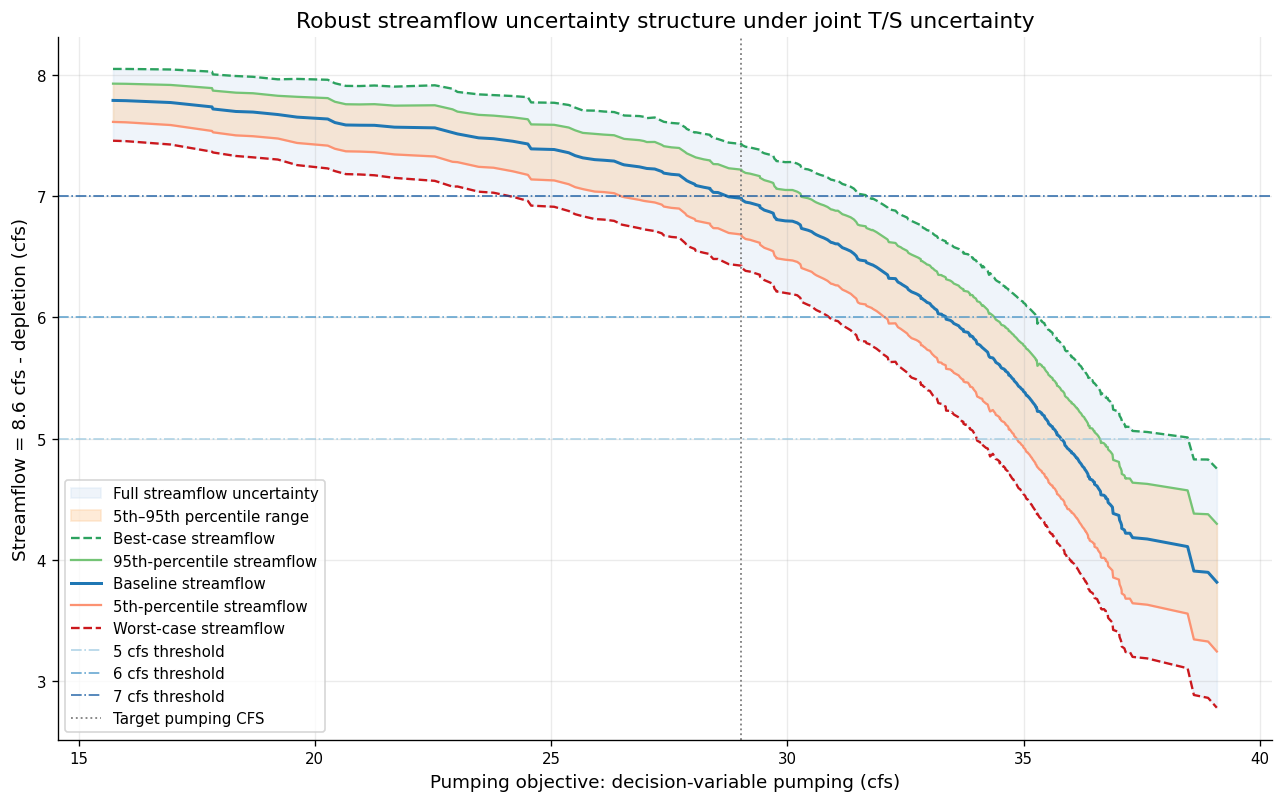

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_full_streamflow_uncertainty_structure_vs_pumping.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_full_streamflow_uncertainty_structure_vs_pumping.png


In [124]:
fig, ax = plt.subplots(figsize=(10.8, 6.8))

ax.fill_between(
    x,
    plot_df["worst_case_streamflow_cfs"],
    plot_df["best_case_streamflow_cfs"],
    color=FULL_FILL_COLOR,
    alpha=0.28,
    label="Full streamflow uncertainty",
)
ax.fill_between(
    x,
    plot_df["streamflow_p05_cfs"],
    plot_df["streamflow_p95_cfs"],
    color=PERCENTILE_FILL_COLOR,
    alpha=0.42,
    label="5th–95th percentile range",
)

ax.plot(x, plot_df["best_case_streamflow_cfs"], marker="", markersize=3, linewidth=1.4, linestyle="--", color=BEST_COLOR, label="Best-case streamflow")
ax.plot(x, plot_df["streamflow_p95_cfs"], marker="", markersize=3, linewidth=1.35, color=P95_COLOR, label="95th-percentile streamflow")
ax.plot(x, plot_df["baseline_streamflow_cfs"], marker="", markersize=3, linewidth=1.8, color=BASELINE_COLOR, label="Baseline streamflow")
ax.plot(x, plot_df["streamflow_p05_cfs"], marker="", markersize=3, linewidth=1.35, color=P05_COLOR, label="5th-percentile streamflow")
ax.plot(x, plot_df["worst_case_streamflow_cfs"], marker="", markersize=3, linewidth=1.4, linestyle="--", color=WORST_COLOR, label="Worst-case streamflow")

for threshold in STREAMFLOW_THRESHOLDS_CFS:
    ax.axhline(float(threshold), linestyle="-.", linewidth=1.0, alpha=0.8, color=THRESHOLD_COLORS[float(threshold)], label=f"{threshold:g} cfs threshold")

ax.axvline(x0, color="0.50", linestyle=":", linewidth=1.1, label="Target pumping CFS")

ax.set_xlabel("Pumping objective: decision-variable pumping (cfs)")
ax.set_ylabel("Streamflow = 8.6 cfs - depletion (cfs)")
ax.set_title("Robust streamflow uncertainty structure under joint T/S uncertainty")
ax.legend(loc="best", ncol=1)

fig_path = OUTPUT_DIR / "304_full_streamflow_uncertainty_structure_vs_pumping.png"
up.save_figure(fig, fig_path)
print("Saved:", fig_path)


## 7. Figure: local full streamflow uncertainty

This local figure focuses on the streamflow uncertainty near the selected pumping target.

Key visual elements:

- **light blue fill** = full streamflow uncertainty (best to worst)
- **light orange fill** = 5th to 95th percentile range
- **blue line** = baseline streamflow
- **green dashed line** = best-case boundary
- **red dashed line** = worst-case boundary
- **vertical dotted line** = target pumping location
- **three vertical markers at the same pumping location**:
  - full uncertainty (thickest)
  - worst-case shortfall relative to the local threshold
  - 5th-percentile shortfall relative to the local threshold


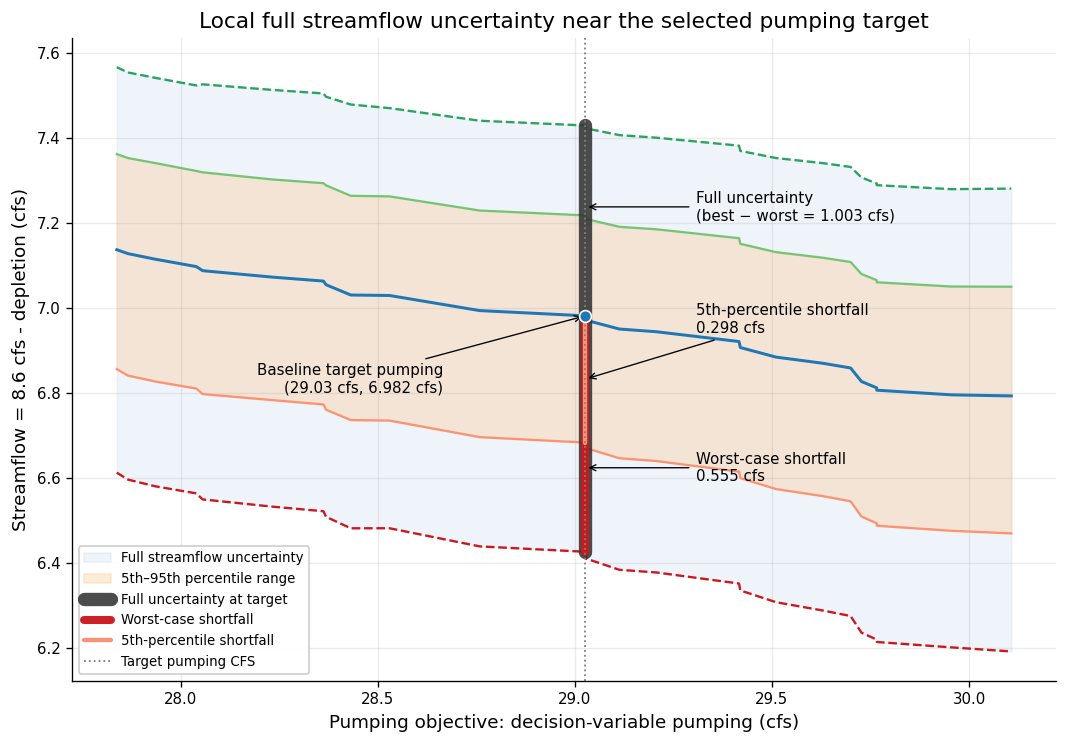

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_local_full_streamflow_uncertainty.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_local_full_streamflow_uncertainty.png


In [131]:
fig, ax = plt.subplots(figsize=(9.0, 6.3))

ax.fill_between(
    local_x,
    local_df["worst_case_streamflow_cfs"],
    local_df["best_case_streamflow_cfs"],
    color=FULL_FILL_COLOR,
    alpha=0.28,
    label="Full streamflow uncertainty",
)
ax.fill_between(
    local_x,
    local_df["streamflow_p05_cfs"],
    local_df["streamflow_p95_cfs"],
    color=PERCENTILE_FILL_COLOR,
    alpha=0.42,
    label="5th–95th percentile range",
)

ax.plot(local_x, local_df["baseline_streamflow_cfs"], linewidth=1.8, color=BASELINE_COLOR) #, label="Baseline streamflow")
ax.plot(local_x, local_df["streamflow_p95_cfs"], linewidth=1.35, color=P95_COLOR) #, label="95th-percentile streamflow")
ax.plot(local_x, local_df["streamflow_p05_cfs"], linewidth=1.35, color=P05_COLOR) #, label="5th-percentile streamflow")
ax.plot(local_x, local_df["best_case_streamflow_cfs"], linestyle="--", linewidth=1.4, color=BEST_COLOR) #, label="Best-case boundary")
ax.plot(local_x, local_df["worst_case_streamflow_cfs"], linestyle="--", linewidth=1.4, color=WORST_COLOR) #, label="Worst-case boundary")

ax.scatter([x0], [baseline0], s=50, zorder=4, color=BASELINE_COLOR, edgecolors="white")

# All vertical markers at the same x location.
ax.plot([x0, x0], [worst0, best0], linewidth=8.0, color="0.20", alpha=0.88, solid_capstyle="round", label="Full uncertainty at target")
if worst_shortfall0 > 0:
    ax.plot([x0, x0], [worst0, threshold0], linewidth=4.8, color=WORST_COLOR, alpha=0.96, solid_capstyle="round", label="Worst-case shortfall")
if p05_shortfall0 > 0:
    ax.plot([x0, x0], [p05_0, threshold0], linewidth=2.6, color=P05_COLOR, alpha=1.0, solid_capstyle="round", label="5th-percentile shortfall")

# Refined annotation placement.
baseline_text_y = 0.5 * (baseline0 + p05_0)
worst_text_y = 0.5 * (worst0 + threshold0) - 0.08
p05_text_y = 0.5 * (p05_0 + threshold0)

# Baseline: move a little to the right relative to the prior version.
ax.annotate(
    f"Baseline target pumping\n({x0:.2f} cfs, {baseline0:.3f} cfs)",
    xy=(x0, baseline0),
    xytext=(x0 - 0.36, baseline_text_y),
    textcoords="data",
    ha="right",
    va="center",
    fontsize=9,
    arrowprops=dict(arrowstyle="->", lw=0.8),
)

# Full uncertainty: place just above the 95th-percentile streamflow with a horizontal arrow.
ax.annotate(
    f"Full uncertainty\n(best − worst = {full_uncertainty0:.3f} cfs)",
    xy=(x0, p95_0 + 0.02),
    xytext=(x0 + 0.28, p95_0 + 0.02),
    textcoords="data",
    ha="left",
    va="center",
    fontsize=9,
    arrowprops=dict(arrowstyle="->", lw=0.8),
)

# Worst-case shortfall: shift down slightly and use a horizontal arrow.
if worst_shortfall0 > 0:
    ax.annotate(
        f"Worst-case shortfall\n{worst_shortfall0:.3f} cfs",
        xy=(x0, worst_text_y),
        xytext=(x0 + 0.28, worst_text_y),
        textcoords="data",
        ha="left",
        va="center",
        fontsize=9,
        arrowprops=dict(arrowstyle="->", lw=0.8),
    )

if p05_shortfall0 > 0:
    ax.annotate(
        f"5th-percentile shortfall\n{p05_shortfall0:.3f} cfs",
        xy=(x0, p05_text_y),
        xytext=(x0 + 0.28, p05_text_y + 0.14),
        textcoords="data",
        ha="left",
        va="center",
        fontsize=9,
        arrowprops=dict(arrowstyle="->", lw=0.8),
    )
ax.axvline(x0, color="0.50", linestyle=":", linewidth=1.1, label="Target pumping CFS")

ax.set_xlabel("Pumping objective: decision-variable pumping (cfs)")
ax.set_ylabel("Streamflow = 8.6 cfs - depletion (cfs)")
ax.set_title("Local full streamflow uncertainty near the selected pumping target")
ax.legend(loc="best", fontsize=8, framealpha=0.95)

fig_path = OUTPUT_DIR / "304_local_full_streamflow_uncertainty.png"
up.save_figure(fig, fig_path)
print("Saved:", fig_path)


## 8. Figure: probability of falling below each streamflow threshold

This figure shows the **probability of shortfall** at each pumping design.

The three threshold curves use three shades of blue.
The reliability reference lines use greyscale colors and different line styles so that 80%, 90%, and 95% are easy to distinguish.


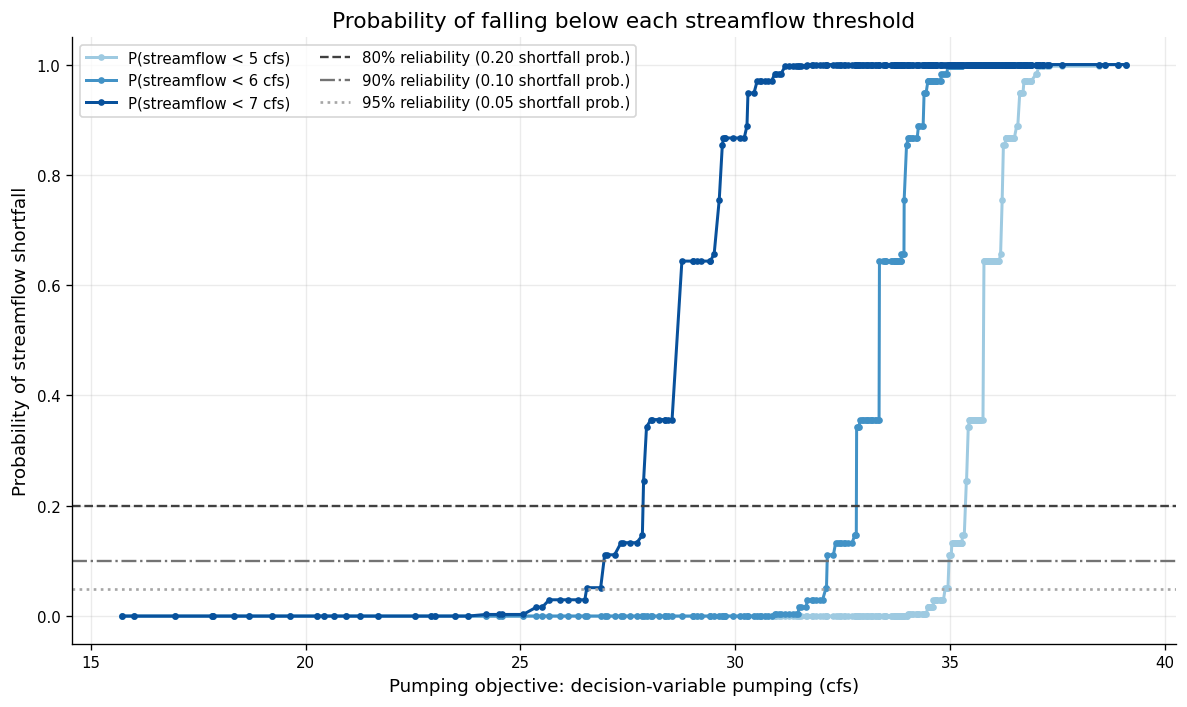

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_probability_below_streamflow_thresholds_vs_pumping.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_probability_below_streamflow_thresholds_vs_pumping.png


In [126]:
fig, ax = plt.subplots(figsize=(10.0, 6.0))

for threshold in STREAMFLOW_THRESHOLDS_CFS:
    suffix = safe_col_suffix(threshold)
    ax.plot(
        x,
        plot_df[f"prob_below_{suffix}_cfs"],
        marker="o",
        markersize=3,
        linewidth=1.8,
        color=THRESHOLD_COLORS[float(threshold)],
        label=f"P(streamflow < {threshold:g} cfs)",
    )

for reliability, style in RELIABILITY_STYLES.items():
    shortfall_prob = 1.0 - float(reliability)
    ax.axhline(
        shortfall_prob,
        color=style["color"],
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
        label=f"{int(reliability*100)}% reliability ({shortfall_prob:.2f} shortfall prob.)",
    )

ax.set_xlabel("Pumping objective: decision-variable pumping (cfs)")
ax.set_ylabel("Probability of streamflow shortfall")
ax.set_title("Probability of falling below each streamflow threshold")
ax.legend(loc="best", ncol=2)

fig_path = OUTPUT_DIR / "304_probability_below_streamflow_thresholds_vs_pumping.png"
up.save_figure(fig, fig_path)
print("Saved:", fig_path)


## 9. Figure: expected shortfall below each streamflow threshold

This figure shows the **magnitude-based** shortfall risk.

For each pumping design and threshold:

```text
expected shortfall = probability-weighted average of max(threshold − streamflow, 0)
```

These curves use the same blue threshold palette as the probability plot and the robust-yield bar chart.


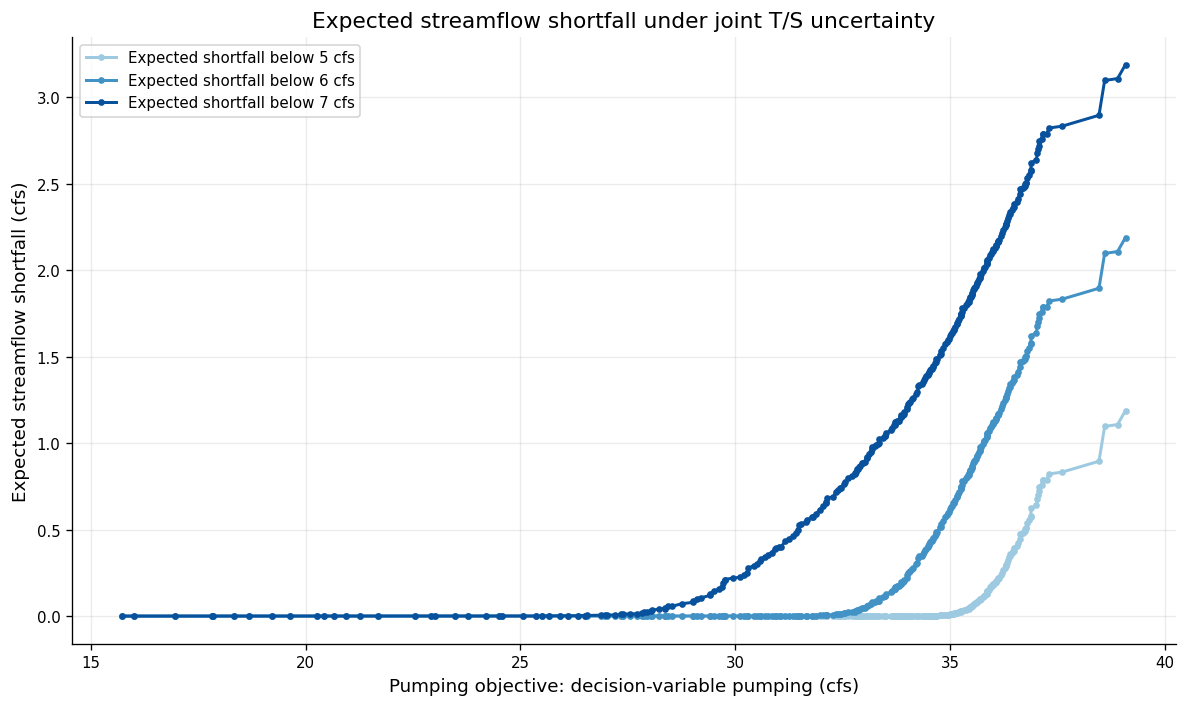

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_expected_streamflow_shortfall_vs_pumping.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_expected_streamflow_shortfall_vs_pumping.png


In [127]:
fig, ax = plt.subplots(figsize=(10.0, 6.0))

for threshold in STREAMFLOW_THRESHOLDS_CFS:
    suffix = safe_col_suffix(threshold)
    ax.plot(
        x,
        plot_df[f"expected_shortfall_below_{suffix}_cfs"],
        marker="o",
        markersize=3,
        linewidth=1.8,
        color=THRESHOLD_COLORS[float(threshold)],
        label=f"Expected shortfall below {threshold:g} cfs",
    )

ax.set_xlabel("Pumping objective: decision-variable pumping (cfs)")
ax.set_ylabel("Expected streamflow shortfall (cfs)")
ax.set_title("Expected streamflow shortfall under joint T/S uncertainty")
ax.legend(loc="best")

fig_path = OUTPUT_DIR / "304_expected_streamflow_shortfall_vs_pumping.png"
up.save_figure(fig, fig_path)
print("Saved:", fig_path)


## 10. Figure: robust yield by threshold and reliability

This grouped bar chart is organized **by threshold**.

- Each threshold group (5, 6, and 7 cfs) has its own blue shade.
- Within each threshold group, the three bars represent:
  - 80% reliability
  - 90% reliability
  - 95% reliability
- The bars within a group share the same base color and are distinguished by alpha and hatch.

Only the reliability-style legend is shown, because the threshold grouping is already clear from the x-axis groups and bar colors.


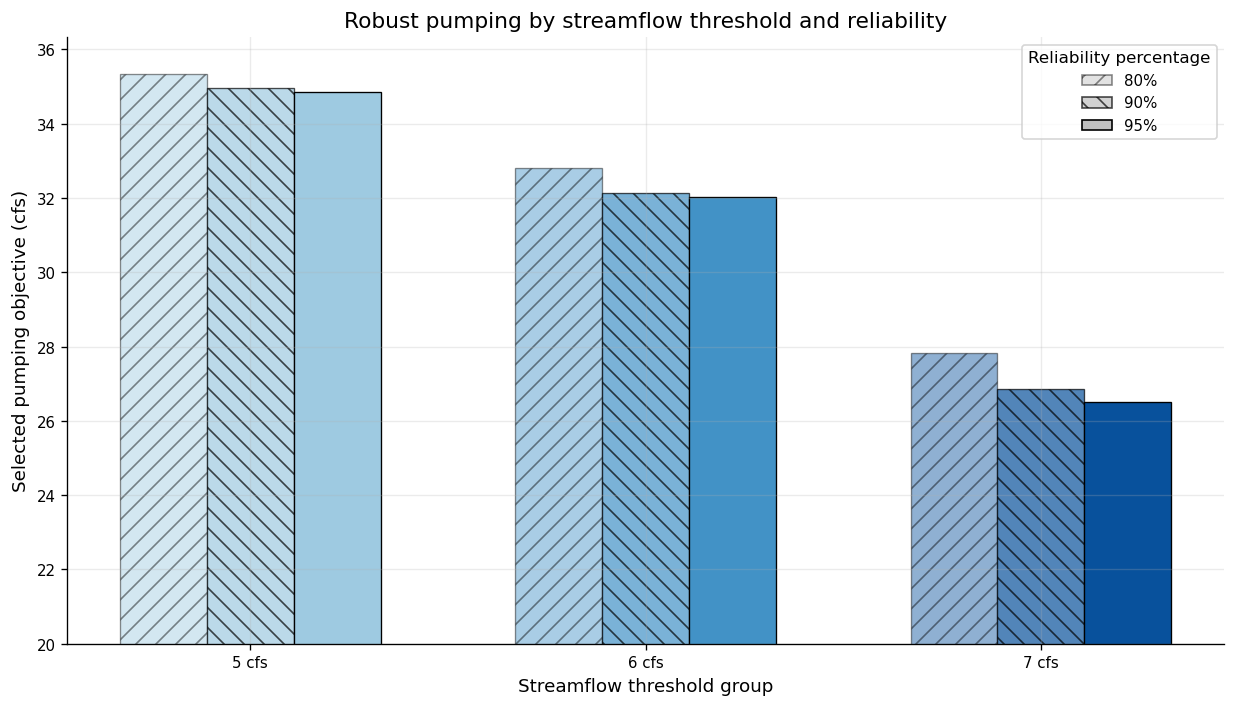

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_robust_yield_by_threshold_and_reliability.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_robust_yield_by_threshold_and_reliability.png


In [139]:
plot_policy = policy_summary.loc[policy_summary["status"] == "Feasible"].copy()

if plot_policy.empty:
    print("No feasible robust-yield selections to plot.")
else:
    threshold_values = sorted(plot_policy["streamflow_threshold_cfs"].unique())
    reliability_values = sorted(plot_policy["reliability_level"].unique())

    fig, ax = plt.subplots(figsize=(10.4, 6.0))
    xloc = np.arange(len(threshold_values))
    width = 0.22
    ymax = []

    for j, reliability in enumerate(reliability_values):
        offset = (j - (len(reliability_values)-1)/2) * width
        heights = []
        colors = []
        alphas = []
        hatches = []
        ymax.append(heights)

        for threshold in threshold_values:
            row = plot_policy.loc[
                (plot_policy["streamflow_threshold_cfs"] == threshold)
                & (plot_policy["reliability_level"] == reliability)
            ]
            heights.append(float(row["selected_pumping_cfs"].iloc[0]) if not row.empty else np.nan)
            colors.append(THRESHOLD_COLORS[float(threshold)])
            alphas.append(RELIABILITY_BAR_STYLES[float(reliability)]["alpha"])
            hatches.append(RELIABILITY_BAR_STYLES[float(reliability)]["hatch"])

        bars = ax.bar(
            xloc + offset,
            heights,
            width=width,
            color=colors,
            edgecolor="black",
            linewidth=0.8,
        )

        for bar, alpha, hatch in zip(bars, alphas, hatches):
            bar.set_alpha(alpha)
            bar.set_hatch(hatch)

    ax.set_xticks(xloc)
    ax.set_xticklabels([f"{t:g} cfs" for t in threshold_values])
    ax.set_ylim(20, max(max(ymax))+1)
    ax.set_xlabel("Streamflow threshold group")
    ax.set_ylabel("Selected pumping objective (cfs)")
    ax.set_title("Robust pumping by streamflow threshold and reliability")

    reliability_handles = [
        Patch(
            facecolor="0.75",
            edgecolor="black",
            alpha=RELIABILITY_BAR_STYLES[r]["alpha"],
            hatch=RELIABILITY_BAR_STYLES[r]["hatch"],
            label=f"{int(r*100)}%"
        )
        for r in reliability_values
    ]
    ax.legend(handles=reliability_handles, loc="best", title="Reliability percentage")

    fig_path = OUTPUT_DIR / "304_robust_yield_by_threshold_and_reliability.png"
    up.save_figure(fig, fig_path)
    print("Saved:", fig_path)


## 11. Write a short Markdown decision summary

In [129]:
policy_lines = []
for _, row in policy_summary.iterrows():
    if row["status"] != "Feasible":
        continue
    policy_lines.append(
        f"| {row['streamflow_threshold_cfs']:.2f} | {row['reliability_level']:.2f} | {row.get('selected_member_label', row['selected_member'])} | {row['selected_pumping_cfs']:.4f} | {row['selected_probability_below_threshold']:.4f} | {row['selected_expected_shortfall_cfs']:.4f} |"
    )

summary_text = f"""# 304 Robust Decision Summary

## Purpose

This notebook translates the joint T/S uncertainty results into decision-oriented quantities:

- the global streamflow uncertainty structure
- a local uncertainty interpretation near a selected pumping target
- probability of shortfall
- expected shortfall magnitude
- robust pumping limits by threshold and reliability

## Robust-yield selections

| Streamflow threshold (cfs) | Reliability | Selected member | Selected pumping (cfs) | Probability below threshold | Expected shortfall (cfs) |
|---:|---:|---|---:|---:|---:|
{chr(10).join(policy_lines)}

## Interpretation

- The global streamflow uncertainty figure shows the best-case, baseline, percentile, and worst-case structure under joint T/S uncertainty.
- The local uncertainty figure zooms in on one pumping neighborhood and illustrates the full uncertainty range plus two shortfall magnitudes relative to the local threshold.
- The probability and expected-shortfall plots translate that uncertainty structure into threshold-based risk metrics.
- The robust-yield bar chart shows how the maximum acceptable pumping objective changes as the streamflow threshold and reliability requirement become more stringent.
"""

summary_path = OUTPUT_DIR / "304_robust_decision_analysis_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")
print(summary_text)
print("Saved:", summary_path)


# 304 Robust Decision Summary

## Purpose

This notebook translates the joint T/S uncertainty results into decision-oriented quantities:

- the global streamflow uncertainty structure
- a local uncertainty interpretation near a selected pumping target
- probability of shortfall
- expected shortfall magnitude
- robust pumping limits by threshold and reliability

## Robust-yield selections

| Streamflow threshold (cfs) | Reliability | Selected member | Selected pumping (cfs) | Probability below threshold | Expected shortfall (cfs) |
|---:|---:|---|---:|---:|---:|
| 5.00 | 0.80 | gen=42_member=7200_pso | 35.3322 | 0.1464 | 0.0335 |
| 5.00 | 0.90 | gen=40_member=6799_pso | 34.9528 | 0.0515 | 0.0078 |
| 5.00 | 0.95 | gen=32_member=5452_pso | 34.8475 | 0.0296 | 0.0053 |
| 6.00 | 0.80 | gen=47_member=7961_pso | 32.8185 | 0.1464 | 0.0280 |
| 6.00 | 0.90 | gen=50_member=8483_pso | 32.1245 | 0.0515 | 0.0053 |
| 6.00 | 0.95 | gen=40_member=6749_pso | 32.0338 | 0.0296 | 0.0042 |
| 7.00 | 0.80 | ge

## 12. List final outputs

In [130]:
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.name)


304_expected_streamflow_shortfall_vs_pumping.png
304_full_streamflow_uncertainty_structure_vs_pumping.png
304_local_full_streamflow_uncertainty.png
304_local_streamflow_uncertainty_relationship_1x2.png
304_local_upper_lower_boundary_interpretation.png
304_probability_below_streamflow_thresholds_vs_pumping.png
304_risk_adjusted_design_scores.csv
304_risk_adjusted_scores_vs_pumping.png
304_robust_decision_analysis_summary.md
304_robust_decision_member_metrics.csv
304_robust_pumping_limit_vs_reliability.png
304_robust_yield_by_threshold_and_reliability.csv
304_robust_yield_by_threshold_and_reliability.png
304_selected_designs_by_risk_aversion.csv
304_vertical_uncertainty_envelope_height_vs_pumping.png
